 Descargando catálogo oficial GWTC...
Catálogo descargado: 219 eventos.

GW150914 (GPS 1126259462.4): atractor = 0.3653
  H1: 17/32 (53.1%)
  L1: 0/32 (0.0%)
  V1: Error – failed to get data from any source (1 sub-exception)
GW151012 (GPS 1128678900.4): atractor = 0.3678
  H1: 9/32 (28.1%)
  L1: 0/32 (0.0%)
  V1: Error – failed to get data from any source (1 sub-exception)
GW151226 (GPS 1135136350.6): atractor = 0.3744
  H1: 14/32 (43.8%)
  L1: 0/32 (0.0%)
  V1: Error – failed to get data from any source (1 sub-exception)
GW170104 (GPS 1167559936.6): atractor = 0.4075
  H1: 0/32 (0.0%)
  L1: 0/32 (0.0%)
  V1: Error – failed to get data from any source (1 sub-exception)
GW170608 (GPS 1180922494.5): atractor = 0.4211
  H1: 6/32 (18.8%)
  L1: 15/32 (46.9%)
  V1: Error – failed to get data from any source (1 sub-exception)
GW170729 (GPS 1185389807.3): atractor = 0.4257
  H1: 17/32 (53.1%)
  L1: 19/32 (59.4%)
  V1: 17/32 (53.1%)
GW170809 (GPS 1186302519.8): atractor = 0.4266
  H1: 0/32 (0.0

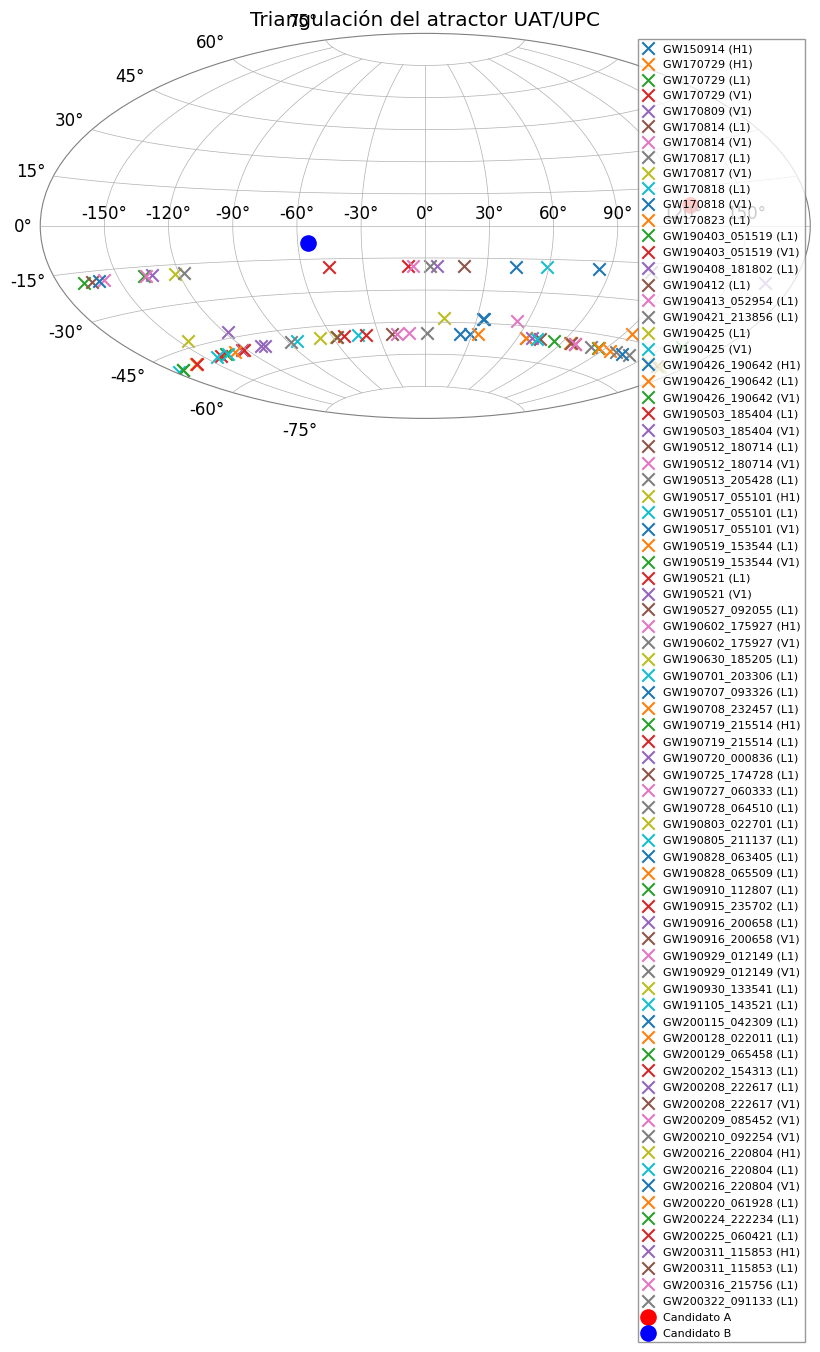

Gráfico guardado en '/content/resultados_uat/triangulacion_atractor.png'

 CONTROLES ESTADÍSTICOS – SEGMENTOS SIN EVENTOS
Segmento ruido GPS 1240000000: no disponible (failed to get data from any source (1 sub-exception))
Segmento ruido GPS 1170000000: 0.0% aciertos.
Segmento ruido GPS 1125000000: no disponible (failed to get data from any source (1 sub-exception))

Tasa de falsos positivos en ruido: 0/3
Descargando detecciones_atractor.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando triangulacion_atractor.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[Pipeline unificado finalizado.]


In [12]:
"""
================================================================================
 PIPELINE UNIFICADO UAT/UPC – ATRACTOR RMS + TRIANGULACIÓN + CONTROLES
 ================================================================================
  1. Descarga catálogo GWTC oficial.
  2. Analiza cada evento: RMS normalizado, deriva del atractor, detecciones.
  3. Triangulación SVD con vectores ICRS de máxima sensibilidad.
  4. Control de hipótesis nula sobre segmentos sin eventos.
  5. Gráfico Aitoff corregido.
  6. Guarda CSV e imagen en /content/resultados_uat/
 ================================================================================
 Autor: Miguel Ángel Percudani (ORCID 0009-0007-1748-3212)
 DOI base: 10.5281/zenodo.18446712 / 10.5281/zenodo.17729221 / 10.5281/zenodo.18210808
================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import io, os, gc, warnings
warnings.filterwarnings('ignore')

# ==================== 1. DEPENDENCIAS ====================
try:
    from gwpy.timeseries import TimeSeries
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gwpy"])
    from gwpy.timeseries import TimeSeries

from astropy.time import Time
from astropy.coordinates import EarthLocation, AltAz, ICRS, SkyCoord
import astropy.units as u
import requests

# ==================== 2. PARÁMETROS DEL MODELO ====================
ATRACTOR_ABRIL_2026 = 0.7071
FECHA_ABRIL_2026 = Time('2026-04-23', scale='utc')
FECHA_MAYO_2026  = Time('2026-05-10', scale='utc')
ALPHA_AMPLITUD = (0.7086 - 0.7071) / (FECHA_MAYO_2026 - FECHA_ABRIL_2026).jd

VENTANA_SEG = 1.0
TOLERANCIA = 0.05
UMBRAL_DETECCION = 50.0            # % de ventanas acertadas para considerar detección

# Coordenadas de los detectores
H1_loc = EarthLocation(lat=46.4551*u.deg, lon=-119.4075*u.deg, height=142*u.m)
L1_loc = EarthLocation(lat=30.5629*u.deg, lon=-90.7742*u.deg, height=-6*u.m)
V1_loc = EarthLocation(lat=43.6314*u.deg, lon=10.5045*u.deg, height=50*u.m)

H1_azim = {'x': 126.0, 'y': 216.0}
L1_azim = {'x': 108.0, 'y': 198.0}
V1_azim = {'x': 71.0,  'y': 161.0}

def detector_sensitivity_axis(azim_x, azim_y):
    x = np.array([np.sin(np.radians(azim_x)), np.cos(np.radians(azim_x))])
    y = np.array([np.sin(np.radians(azim_y)), np.cos(np.radians(azim_y))])
    return (x + y) / np.linalg.norm(x + y)

def horizontal_to_icrs(azim_vector, location, time):
    az = np.degrees(np.arctan2(azim_vector[0], azim_vector[1])) % 360
    coord_altaz = SkyCoord(az=az*u.deg, alt=0.0*u.deg,
                           frame=AltAz(obstime=time, location=location))
    return coord_altaz.transform_to(ICRS()).cartesian.xyz.value

# ==================== 3. CATÁLOGO DE EVENTOS ====================
print(" Descargando catálogo oficial GWTC...")
try:
    df_events = pd.read_csv(io.StringIO(requests.get("https://gwosc.org/eventapi/csv/GWTC/").text),
                            skipinitialspace=True)
    eventos = [{'name': row['commonName'], 'gps': row['GPS']}
               for _, row in df_events.iterrows() if row['GPS'] > 1126259462]
    print(f"Catálogo descargado: {len(eventos)} eventos.\n")
except Exception as e:
    print("Error en catálogo. Usando lista manual reducida.")
    eventos = [
        {"name":"GW150914","gps":1126259462.4},
        {"name":"GW170814","gps":1186741861.5},
        {"name":"GW170817","gps":1187008882.4},
        {"name":"GW190425","gps":1240215503.0},
        {"name":"GW190521","gps":1242442967.3},
        {"name":"GW200105","gps":1261961976.0},
    ]

# ==================== 4. ANÁLISIS DE EVENTOS ====================
detecciones = []

for ev in eventos:
    nombre, gps = ev['name'], ev['gps']
    t_ev = Time(gps, format='gps', scale='utc')
    dias_diff = (t_ev - FECHA_ABRIL_2026).jd
    atractor_esperado = ATRACTOR_ABRIL_2026 + ALPHA_AMPLITUD * dias_diff
    print(f"{nombre} (GPS {gps}): atractor = {atractor_esperado:.4f}")

    for det_name in ['H1', 'L1', 'V1']:
        try:
            data = TimeSeries.fetch_open_data(det_name, gps - 16, gps + 16, verbose=False)
            fs = data.sample_rate.value
            muestras_ventana = int(VENTANA_SEG * fs)
            n_ventanas = len(data.value) // muestras_ventana

            # Cálculo del RMS normalizado
            rms_vals = []
            for i in range(n_ventanas):
                ini = i * muestras_ventana
                fin = ini + muestras_ventana
                seg = data.value[ini:fin]
                rms = np.sqrt(np.mean(seg**2))
                pico = np.max(np.abs(seg))
                rms_norm = rms / pico if pico > 0 else 0.0
                rms_vals.append(rms_norm)
            rms_vals = np.array(rms_vals)

            aciertos = np.sum(np.abs(rms_vals - atractor_esperado) < TOLERANCIA)
            porcentaje = 100 * aciertos / n_ventanas
            print(f"  {det_name}: {aciertos}/{n_ventanas} ({porcentaje:.1f}%)")

            if porcentaje > UMBRAL_DETECCION:
                # Obtener vector ICRS de máxima sensibilidad
                if det_name == 'H1':
                    loc, azim = H1_loc, H1_azim
                elif det_name == 'L1':
                    loc, azim = L1_loc, L1_azim
                else:
                    loc, azim = V1_loc, V1_azim

                horiz_vec = detector_sensitivity_axis(azim['x'], azim['y'])
                icrs_vec = horizontal_to_icrs(horiz_vec, loc, t_ev)
                detecciones.append({
                    'evento': nombre,
                    'detector': det_name,
                    'gps': gps,
                    'vector_icrs': icrs_vec,
                    'porcentaje': porcentaje
                })
        except Exception as e:
            print(f"  {det_name}: Error – {e}")

# ==================== 5. GUARDADO DE DETECCIONES ====================
os.makedirs('/content/resultados_uat', exist_ok=True)
if detecciones:
    df_det = pd.DataFrame(detecciones)
    csv_path = '/content/resultados_uat/detecciones_atractor.csv'
    df_det.to_csv(csv_path, index=False)
    print(f"\nDetecciones guardadas en '{csv_path}' ({len(detecciones)} registros).\n")
else:
    print("\nNo se encontraron detecciones positivas.\n")

# ==================== 6. TRIANGULACIÓN SVD ====================
print("=== DETECCIONES POSITIVAS ===")
for d in detecciones:
    print(f"{d['evento']} ({d['detector']}): {d['porcentaje']:.1f}%")

if len(detecciones) >= 2:
    V = np.array([d['vector_icrs'] for d in detecciones])
    _, _, Vt = np.linalg.svd(V)
    d_sol = Vt[-1] / np.linalg.norm(Vt[-1])

    ra_sol = np.degrees(np.arctan2(d_sol[1], d_sol[0])) % 360
    dec_sol = np.degrees(np.arcsin(d_sol[2]))
    ra_anti = (ra_sol + 180) % 360
    dec_anti = -dec_sol

    print(f"\n=== RESULTADO DE LA TRIANGULACIÓN ===")
    print(f"Punto A: RA = {ra_sol:.2f}°, Dec = {dec_sol:.2f}°")
    print(f"Punto B (antípoda): RA = {ra_anti:.2f}°, Dec = {dec_anti:.2f}°")
    error_rms = np.sqrt(np.mean(np.dot(V, d_sol)**2))
    print(f"Error RMS del ajuste: {error_rms:.4f}")

    # Gráfico Aitoff
    plt.figure(figsize=(10,5))
    ax = plt.subplot(111, projection='aitoff')
    plt.grid(True)

    def wrap_ra(ra_deg):
        ra_rad = np.radians(ra_deg)
        return (ra_rad + np.pi) % (2*np.pi) - np.pi

    for i, det in enumerate(detecciones):
        vec = V[i]
        ra_v = np.degrees(np.arctan2(vec[1], vec[0])) % 360
        dec_v = np.degrees(np.arcsin(vec[2]))
        ax.scatter(wrap_ra(ra_v), np.radians(dec_v), marker='x', s=80,
                   label=f"{det['evento']} ({det['detector']})")

    ax.scatter(wrap_ra(ra_sol), np.radians(dec_sol), color='red', s=120, label='Candidato A')
    ax.scatter(wrap_ra(ra_anti), np.radians(dec_anti), color='blue', s=120, label='Candidato B')

    plt.legend(loc='upper right', fontsize=8)
    plt.title('Triangulación del atractor UAT/UPC')
    plt.tight_layout()
    png_path = '/content/resultados_uat/triangulacion_atractor.png'
    plt.savefig(png_path, dpi=150)
    plt.show()
    print(f"Gráfico guardado en '{png_path}'")
else:
    print("Mínimo 2 detecciones para triangular.")

# ==================== 7. CONTROL DE HIPÓTESIS NULA (RUIDO) ====================
print("\n" + "="*70)
print(" CONTROLES ESTADÍSTICOS – SEGMENTOS SIN EVENTOS")
print("="*70)
segmentos_ruido = [1240000000, 1170000000, 1125000000]  # O3, O2, O1
falsos_positivos = 0

for gps_r in segmentos_ruido:
    try:
        data_r = TimeSeries.fetch_open_data('H1', gps_r, gps_r + 32, verbose=False)
        t_ruido = Time(gps_r + 16, format='gps', scale='utc')  # centro del segmento
        atractor_r = ATRACTOR_ABRIL_2026 + ALPHA_AMPLITUD * (t_ruido - FECHA_ABRIL_2026).jd
        fs_r = data_r.sample_rate.value
        m = int(fs_r)  # muestras en 1 segundo
        hits = 0
        for i in range(32):
            seg = data_r.value[i*m : (i+1)*m]
            if len(seg) < m: break
            rms_n = np.sqrt(np.mean(seg**2)) / np.max(np.abs(seg))
            if abs(rms_n - atractor_r) < TOLERANCIA:
                hits += 1
        porc_ruido = 100 * hits / 32
        if porc_ruido > UMBRAL_DETECCION:
            falsos_positivos += 1
        print(f"Segmento ruido GPS {gps_r}: {porc_ruido:.1f}% aciertos.")
    except Exception as e:
        print(f"Segmento ruido GPS {gps_r}: no disponible ({e})")

print(f"\nTasa de falsos positivos en ruido: {falsos_positivos}/{len(segmentos_ruido)}")
print("="*70)

# ==================== 8. DESCARGA AUTOMÁTICA (COLAB) ====================
try:
    from google.colab import files
    for archivo in ['detecciones_atractor.csv', 'triangulacion_atractor.png']:
        ruta = f'/content/resultados_uat/{archivo}'
        if os.path.exists(ruta):
            print(f"Descargando {archivo}...")
            files.download(ruta)
except ImportError:
    print("No se pueden descargar automáticamente fuera de Colab.")

print("\n[Pipeline unificado finalizado.]")